**1. Install Library**

In [7]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, IsolationForest

from xgboost import XGBClassifier

from google.colab import files

**2. Upload dan Load Dataset**

In [8]:
uploaded = files.upload()

df = pd.read_csv("heart.csv")
target_col = "HeartDisease"

print("Dataset shape:", df.shape)
display(df.head())

Saving heart.csv to heart (1).csv
Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**2A. Eksplorasi Data - Visualisasi Distribusi Target**

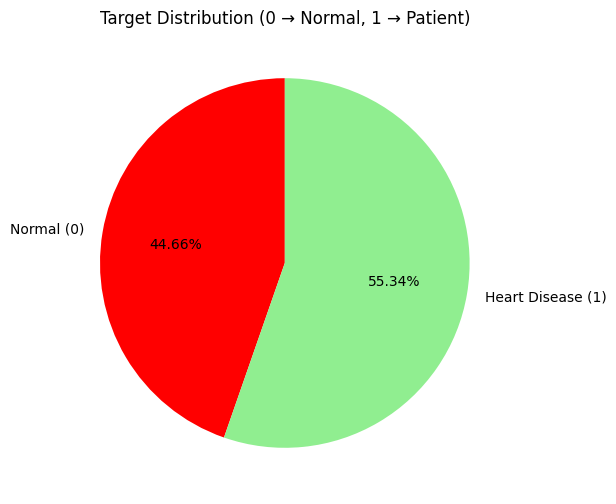

In [9]:
vc = df[target_col].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    vc,
    labels=["Normal (0)", "Heart Disease (1)"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["red", "lightgreen"]
)
plt.title("Target Distribution (0 → Normal, 1 → Patient)")
plt.show()

**2B. Eksplorasi Data - Distribusi Gender**

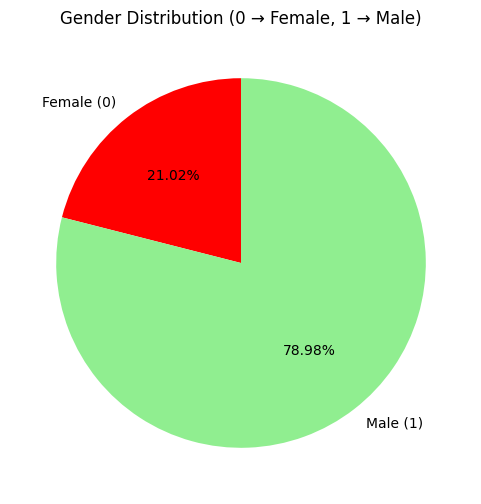

In [10]:
if "Sex" in df.columns:
    vc = df["Sex"].value_counts()

    female_count = vc.get("F", 0)
    male_count   = vc.get("M", 0)

    plt.figure(figsize=(6,6))
    plt.pie(
        [female_count, male_count],
        labels=["Female (0)", "Male (1)"],
        autopct="%1.2f%%",
        startangle=90,
        colors=["red", "lightgreen"]
    )

    plt.title("Gender Distribution (0 → Female, 1 → Male)")
    plt.show()

**2C. Eksplorasi Data - Distribusi 12 Atribut**

/tmp/ipython-input-422936066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
/tmp/ipython-input-422936066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
/tmp/ipython-input-422936066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="Set2")
/tmp/ipython-input-422936066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

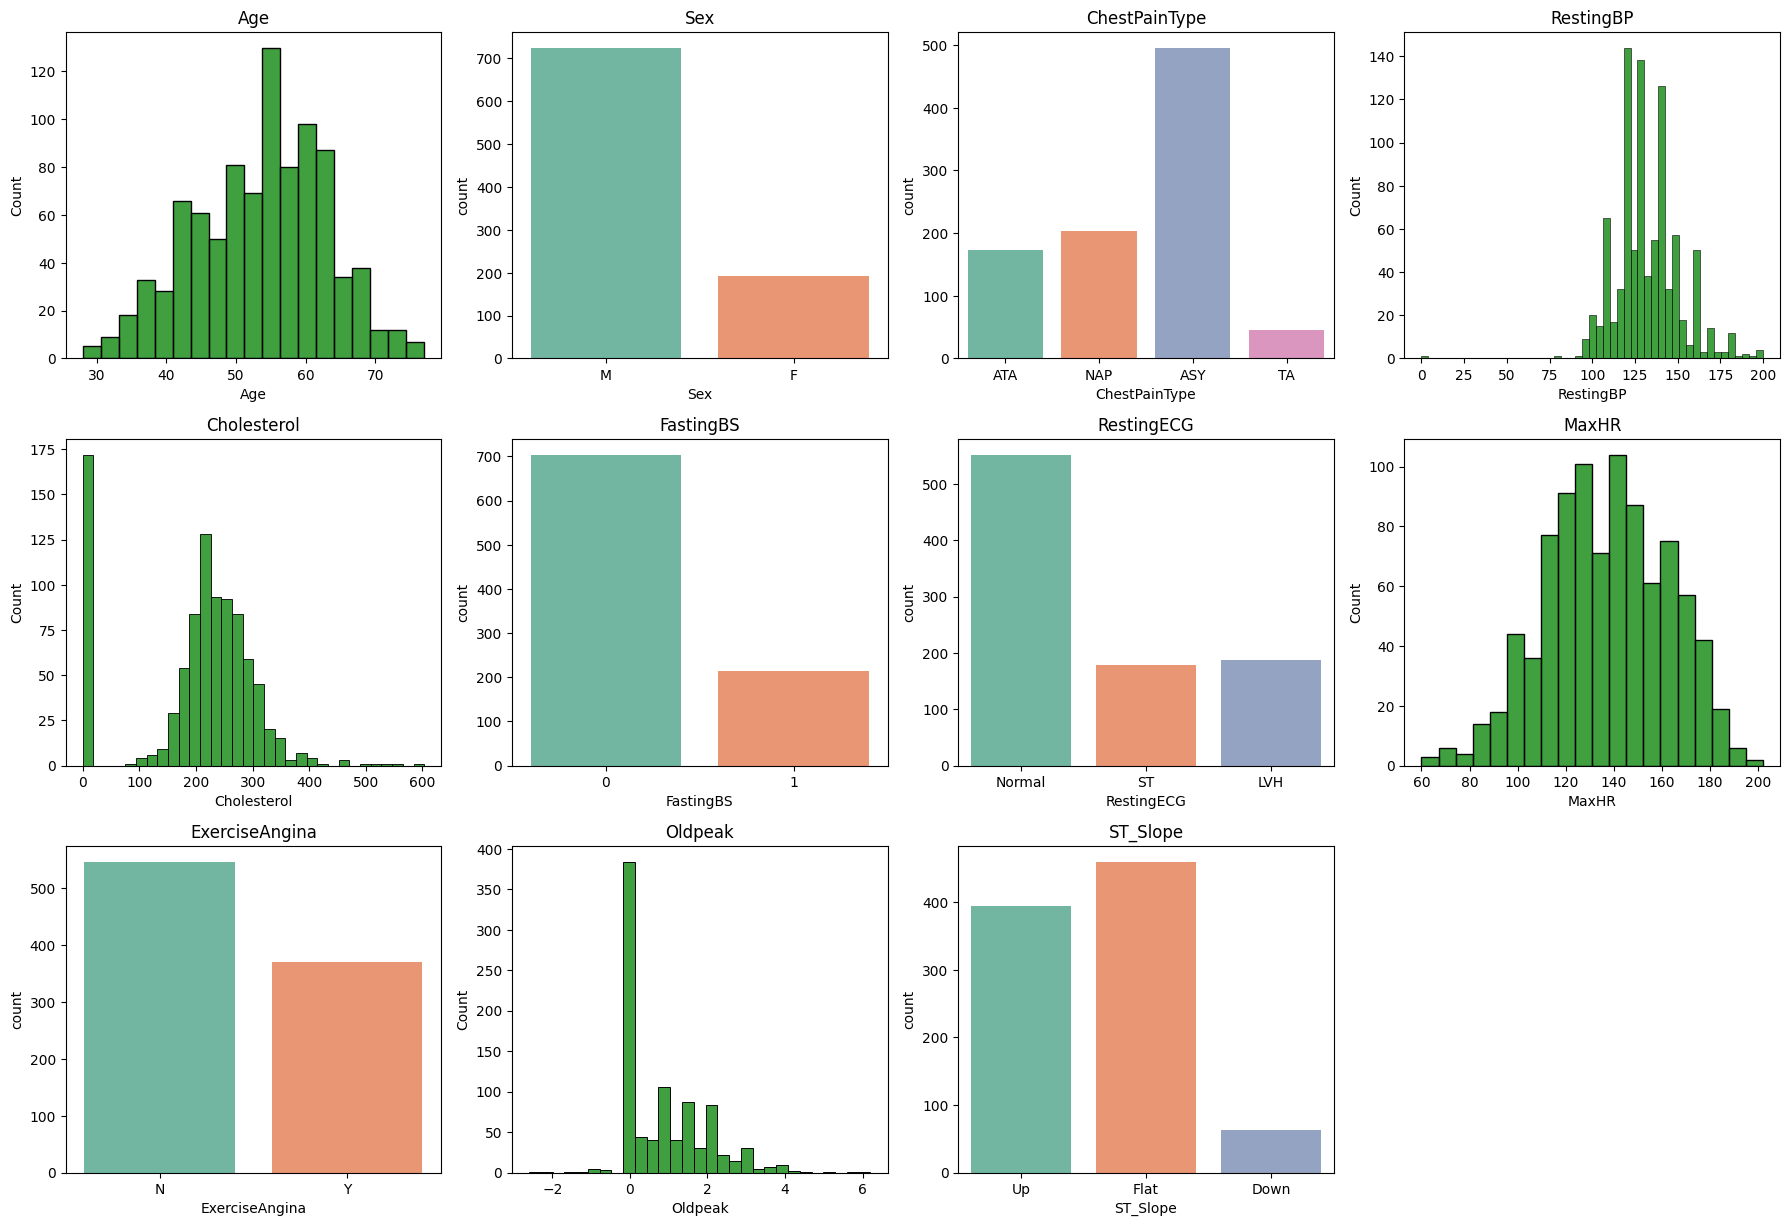

In [11]:
plt.figure(figsize=(18,16))

all_features = df.columns.tolist()
all_features.remove(target_col)

for i, col in enumerate(all_features, 1):
    plt.subplot(4, 4, i)
    if df[col].dtype != "object" and df[col].nunique() > 10:
        # numeric → histogram
        sns.histplot(df[col], kde=False, color="green")
    else:
        # categorical → countplot
        sns.countplot(x=df[col], palette="Set2")

    plt.title(col)

plt.tight_layout()
plt.show()

**3. Handling of Missing Values - Mean Imputation**

In [12]:
print("Jumlah missing values sebelum imputasi:")
print(df.isna().sum())

if df.isna().sum().sum() == 0:
    print("\nTidak ada missing values. Tidak dilakukan imputasi.")
else:
    print("Melakukan imputasi mean per kelas...")

    num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols_all = [c for c in num_cols_all if c != target_col]

    def class_mean_impute(df, numeric_cols, target):
        newdf = df.copy()
        for col in numeric_cols:
            if newdf[col].isna().sum() > 0:
                means = newdf.groupby(target)[col].transform("mean")
                newdf[col] = newdf[col].fillna(means)
                newdf[col] = newdf[col].fillna(newdf[col].mean())
        return newdf

    df = class_mean_impute(df, num_cols_all, target_col)

print("\nMissing values setelah imputasi:")
print(df.isna().sum())

Jumlah missing values sebelum imputasi:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Tidak ada missing values. Tidak dilakukan imputasi.

Missing values setelah imputasi:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


**4. Experiment 1 - Preprocessing Tanpa Outlier Removal**

In [13]:
df_no_outlier = df.copy()

**4A. Feature Scaling**

In [14]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = MinMaxScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(df_no_outlier[num_cols]), columns=num_cols)

print("=== Hasil Feature Scaling (Numerical Columns) ===")
display(X_num_scaled.head())

=== Hasil Feature Scaling (Numerical Columns) ===


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
0,0.244898,0.70,0.479270,0.788732,0.295455
1,0.428571,0.80,0.298507,0.676056,0.409091
2,0.183673,0.65,0.469320,0.267606,0.295455
3,0.408163,0.69,0.354892,0.338028,0.465909
4,0.530612,0.75,0.323383,0.436620,0.295455


**4B. Encoding Categorical Variables - One Hot Encoding**

In [15]:
cat_cols = ["Sex","ChestPainType","FastingBS","RestingECG","ExerciseAngina","ST_Slope"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = pd.DataFrame(
    encoder.fit_transform(df_no_outlier[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols)
)

print("\n=== Hasil One-Hot Encoding (Categorical Columns) ===")
display(X_cat_encoded.head())


=== Hasil One-Hot Encoding (Categorical Columns) ===


,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


**4C. Menggabungkan Numerical + Categorical**

In [16]:
X1 = pd.concat([X_num_scaled, X_cat_encoded], axis=1)
y1 = df_no_outlier[target_col]

print("\n=== FINAL DATASET (Experiment 1 — Tanpa Outlier) ===")
print("Ukuran X1 :", X1.shape)
print("Ukuran y1:", y1.shape)
display(X1.head())


=== FINAL DATASET (Experiment 1 — Tanpa Outlier) ===
Ukuran X1 : (918, 21)
Ukuran y1: (918,)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.244898,0.70,0.479270,0.788732,0.295455,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.428571,0.80,0.298507,0.676056,0.409091,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.183673,0.65,0.469320,0.267606,0.295455,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,0.408163,0.69,0.354892,0.338028,0.465909,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.530612,0.75,0.323383,0.436620,0.295455,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


**4D. Split Data**

In [17]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

**5. Boxplot Outlier**

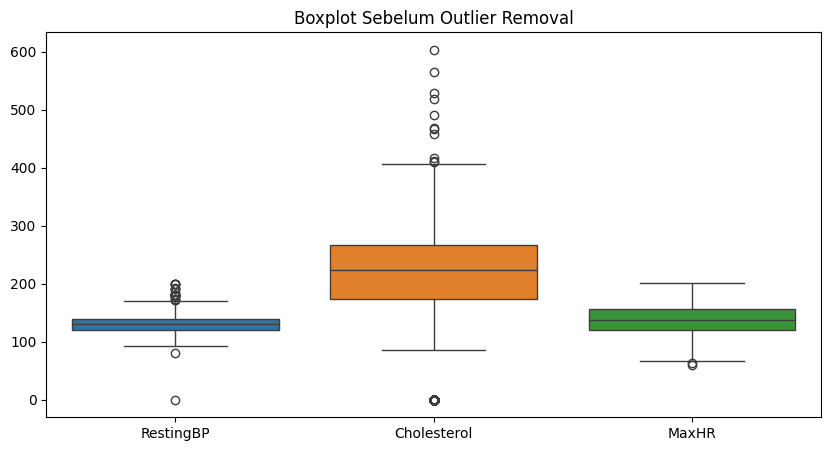

In [18]:
outlier_cols = ["RestingBP", "Cholesterol", "MaxHR"]

plt.figure(figsize=(10,5))
sns.boxplot(data=df[outlier_cols])
plt.title("Boxplot Sebelum Outlier Removal")
plt.show()

**6. Experiment 2 - Dengan Outlier Removal (Isolation Forest)**


Jumlah outlier dibuang: 163


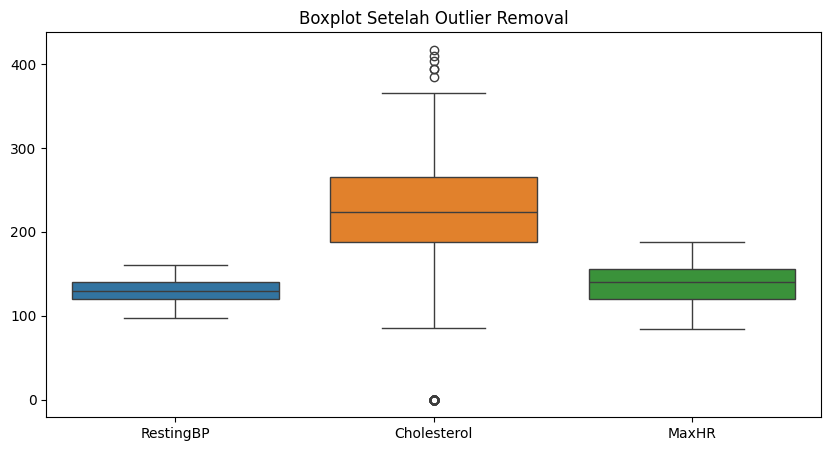


=== FINAL DATASET Experiment 2 ===
Ukuran X2 : (755, 21)
Ukuran y2: (755,)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.229167,0.677419,0.693046,0.846154,0.243902,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.416667,1.000000,0.431655,0.692308,0.365854,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.166667,0.516129,0.678657,0.134615,0.243902,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,0.395833,0.645161,0.513189,0.230769,0.426829,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.520833,0.838710,0.467626,0.365385,0.243902,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [19]:
iso = IsolationForest(random_state=42)
pred = iso.fit_predict(df[outlier_cols])
mask = pred == 1
df_clean = df[mask].reset_index(drop=True)

print("\nJumlah outlier dibuang:", (~mask).sum())

# BOXPLOT SETELAH REMOVAL
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[outlier_cols])
plt.title("Boxplot Setelah Outlier Removal")
plt.show()


# Scaling ulang
scaler2 = MinMaxScaler()
X_num2 = pd.DataFrame(scaler2.fit_transform(df_clean[num_cols]), columns=num_cols)

# Encoding ulang
encoder2 = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat2 = pd.DataFrame(
    encoder2.fit_transform(df_clean[cat_cols]),
    columns=encoder2.get_feature_names_out(cat_cols)
)

# Combine
X2 = pd.concat([X_num2, X_cat2], axis=1)
y2 = df_clean[target_col]

print("\n=== FINAL DATASET Experiment 2 ===")
print("Ukuran X2 :", X2.shape)
print("Ukuran y2:", y2.shape)
display(X2.head())

# Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

**7. Model List**

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Bagging": BaggingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

**8. Fungsi Evaluasi Model**

In [21]:
def evaluate(models, X_train, y_train, X_test, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

        results[name] = {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred),
            "AUC": roc_auc_score(y_test, prob)
        }

    return pd.DataFrame(results).T

**9. HASIL EXPERIMENT 1**

In [22]:
print("\n=========== EXPERIMENT 1 (Tanpa Outlier Removal) ===========")
exp1_results = evaluate(models, X_train1, y_train1, X_test1, y_test1)
display(exp1_results)


=========== EXPERIMENT 1 (Tanpa Outlier Removal) ===========


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.894928,0.897436,0.915033,0.906149,0.932621
Naive Bayes,0.865942,0.886667,0.869281,0.877888,0.917264
Bagging,0.869565,0.877419,0.888889,0.883117,0.915325
AdaBoost,0.873188,0.888158,0.882353,0.885246,0.918460
XGBoost,0.876812,0.899329,0.875817,0.887417,0.935384


**10. HASIL EXPERIMENT 2**

In [23]:
print("\n=========== EXPERIMENT 2 (Dengan Isolation Forest) ===========")
exp2_results = evaluate(models, X_train2, y_train2, X_test2, y_test2)
display(exp2_results)


=========== EXPERIMENT 2 (Dengan Isolation Forest) ===========


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.867841,0.850394,0.907563,0.878049,0.917367
Naive Bayes,0.863436,0.866667,0.873950,0.870293,0.914488
Bagging,0.814978,0.840708,0.798319,0.818966,0.897292
AdaBoost,0.854626,0.852459,0.873950,0.863071,0.902389
XGBoost,0.828194,0.817460,0.865546,0.840816,0.903206


**11. BAR CHART PERFORMANCE**

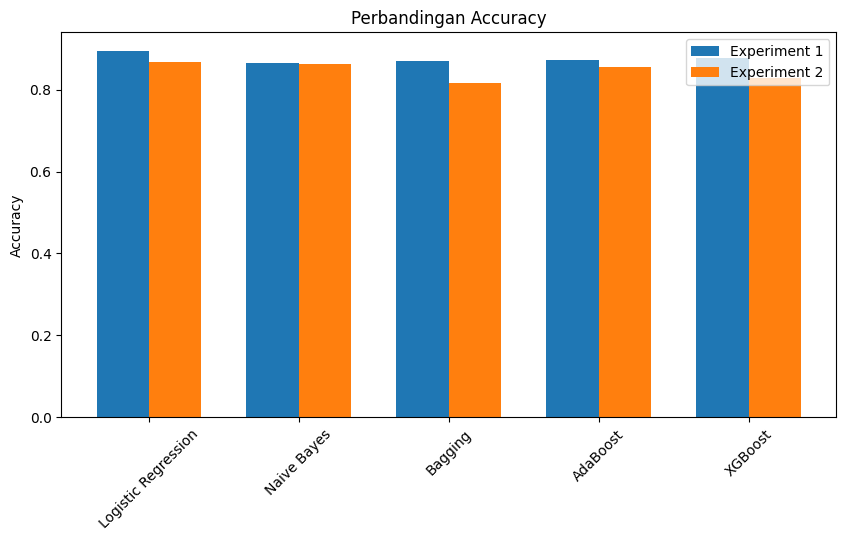

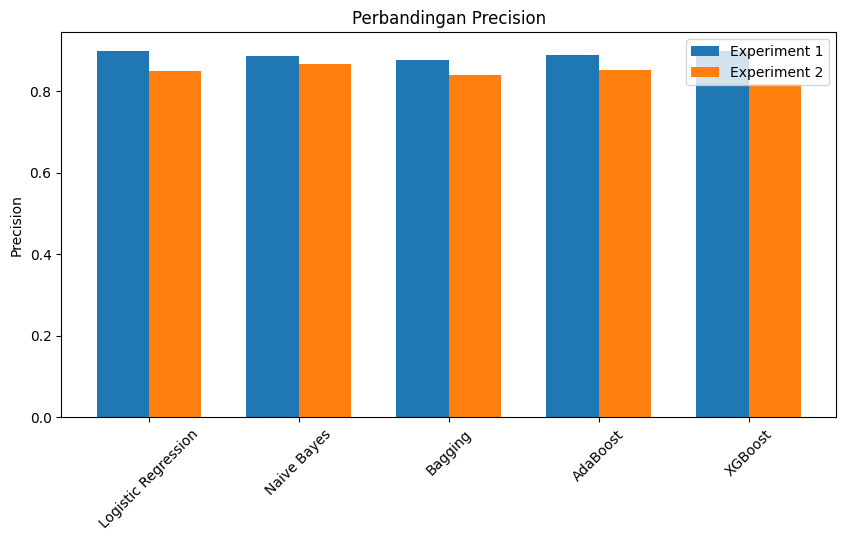

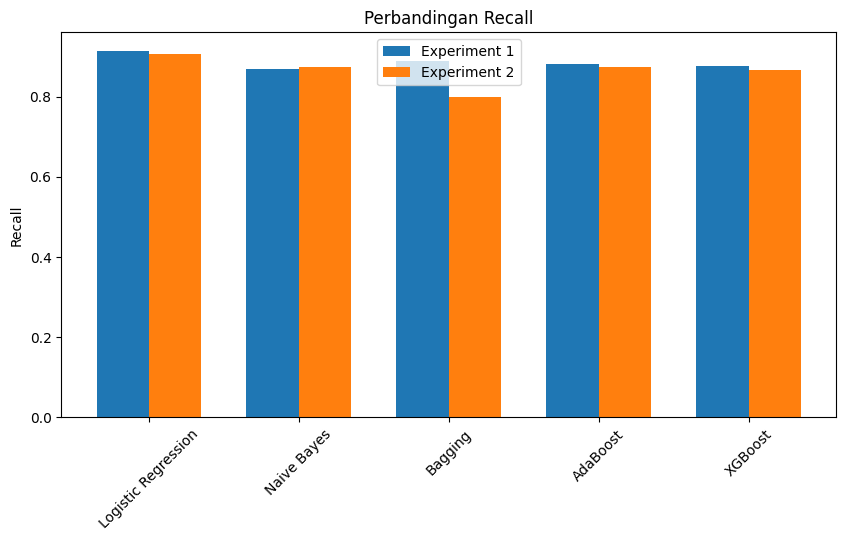

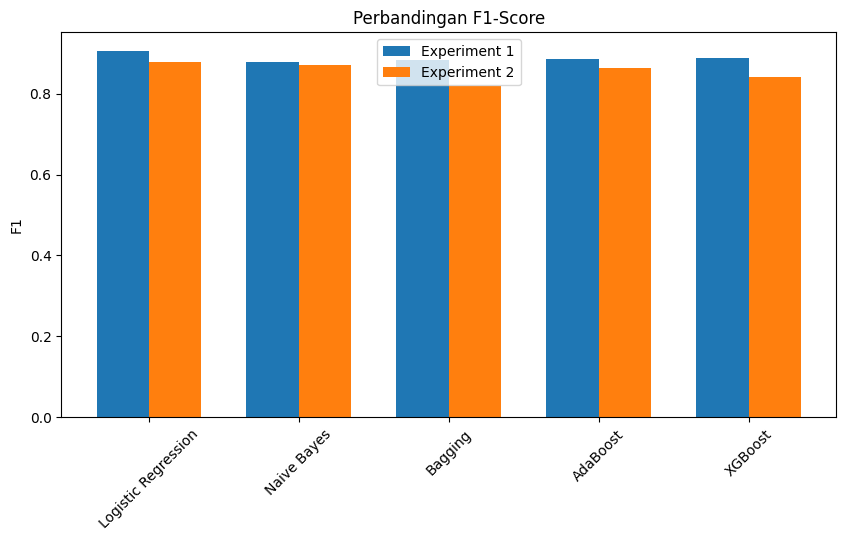

In [24]:
def plot_metric(exp1, exp2, metric, title):
    plt.figure(figsize=(10,5))
    x = np.arange(len(exp1.index))
    w = 0.35
    plt.bar(x - w/2, exp1[metric], width=w, label="Experiment 1")
    plt.bar(x + w/2, exp2[metric], width=w, label="Experiment 2")
    plt.xticks(x, exp1.index, rotation=45)
    plt.title(title)
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_metric(exp1_results, exp2_results, "Accuracy", "Perbandingan Accuracy")
plot_metric(exp1_results, exp2_results, "Precision", "Perbandingan Precision")
plot_metric(exp1_results, exp2_results, "Recall", "Perbandingan Recall")
plot_metric(exp1_results, exp2_results, "F1", "Perbandingan F1-Score")

**12. ROC CURVE SEMUA MODEL**

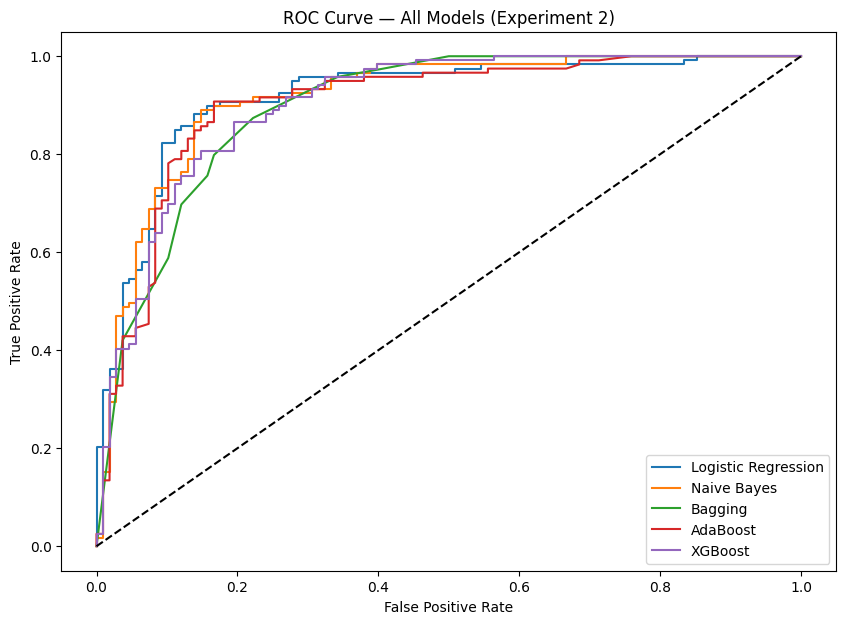

In [25]:
plt.figure(figsize=(10,7))
for name, model in models.items():
    model.fit(X_train2, y_train2)
    prob = model.predict_proba(X_test2)[:,1]
    fpr, tpr, _ = roc_curve(y_test2, prob)
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve — All Models (Experiment 2)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()